In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt

# 1. Establish the connection
conn = psycopg2.connect(
    dbname="chinook_db",
    user="postgres",
    password="zuzu",
    host="localhost",
    port="5432"
)

In [2]:
# 1. Read the SQL file
with open('/Users/apple/Downloads/Chinook_PostgreSql.sql', 'r') as f:
    lines = f.readlines()

# 2. Filter out Database commands AND Meta-commands (\)
# This keeps only the parts that build tables and insert data
clean_sql = "".join([
    line for line in lines 
    if not line.strip().startswith('\\') 
    and 'DATABASE' not in line.upper()
])

# 3. Execute the cleaned script
cur = conn.cursor()
try:
    cur.execute(clean_sql)
    conn.commit()
    print("Success! Tables created and Data inserted.")
except Exception as e:
    conn.rollback()
    print(f"Error: {e}")
finally:
    cur.close()

Error: relation "album" already exists



In [3]:
# Top 5 Selling Products

q1 = """
SELECT 
    t.name AS track_name, 
    COUNT(il.invoice_line_id) AS total_sold
FROM track t
JOIN invoice_line il ON t.track_id = il.track_id
GROUP BY t.track_id, t.name
ORDER BY total_sold DESC
LIMIT 10;
"""
top_products = pd.read_sql_query(q1, conn)
print(top_products)

            track_name  total_sold
0        Right On Time           2
1       Norwegian Wood           2
2             Big Wave           2
3             Selvagem           2
4       Que Luz É Essa           2
5     Bron-Y-Aur Stomp           2
6  Run Silent Run Deep           2
7            Snowblind           2
8          Motorbreath           2
9             Sun King           2


/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_24627/2201447548.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_products = pd.read_sql_query(q1, conn)


In [4]:
# Revenue per Region

q2 = """
SELECT 
    billing_country, 
    SUM(total) AS total_revenue
FROM invoice
GROUP BY billing_country
ORDER BY total_revenue DESC;
"""
region_revenue = pd.read_sql_query(q2, conn)
print(region_revenue.head())

  billing_country  total_revenue
0             USA         523.06
1          Canada         303.96
2          France         195.10
3          Brazil         190.10
4         Germany         156.48


/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_24627/1870207225.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  region_revenue = pd.read_sql_query(q2, conn)


In [5]:
# Monthly Revenue Performance

q3 = """
SELECT 
    TO_CHAR(invoice_date, 'YYYY-MM') AS month, 
    SUM(total) AS monthly_revenue
FROM invoice
GROUP BY month
ORDER BY month ASC;
"""
monthly_perf = pd.read_sql_query(q3, conn)
print(monthly_perf)

      month  monthly_revenue
0   2021-01            35.64
1   2021-02            37.62
2   2021-03            37.62
3   2021-04            37.62
4   2021-05            37.62
5   2021-06            37.62
6   2021-07            37.62
7   2021-08            37.62
8   2021-09            37.62
9   2021-10            37.62
10  2021-11            37.62
11  2021-12            37.62
12  2022-01            52.62
13  2022-02            46.62
14  2022-03            44.62
15  2022-04            37.62
16  2022-05            37.62
17  2022-06            37.62
18  2022-07            37.62
19  2022-08            37.62
20  2022-09            36.63
21  2022-10            37.62
22  2022-11            37.62
23  2022-12            37.62
24  2023-01            37.62
25  2023-02            37.62
26  2023-03            37.62
27  2023-04            51.62
28  2023-05            42.62
29  2023-06            50.62
30  2023-07            37.62
31  2023-08            37.62
32  2023-09            37.62
33  2023-10   

/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_24627/3337121705.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_perf = pd.read_sql_query(q3, conn)


In [6]:
# Customer Spending Rank (Window Function)

q4 = """
SELECT 
    customer_id,
    billing_country,
    total_spent,
    RANK() OVER (PARTITION BY billing_country ORDER BY total_spent DESC) as customer_rank
FROM (
    SELECT 
        customer_id, 
        billing_country, 
        SUM(total) as total_spent
    FROM invoice
    GROUP BY customer_id, billing_country
) AS sales_summary;
"""
customer_rankings = pd.read_sql_query(q4, conn)
print(customer_rankings.head(10))

   customer_id billing_country  total_spent  customer_rank
0           56       Argentina        37.62              1
1           55       Australia        37.62              1
2            7         Austria        42.62              1
3            8         Belgium        37.62              1
4            1          Brazil        39.62              1
5           12          Brazil        37.62              2
6           10          Brazil        37.62              2
7           13          Brazil        37.62              2
8           11          Brazil        37.62              2
9            3          Canada        39.62              1


/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_24627/1682717707.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_rankings = pd.read_sql_query(q4, conn)


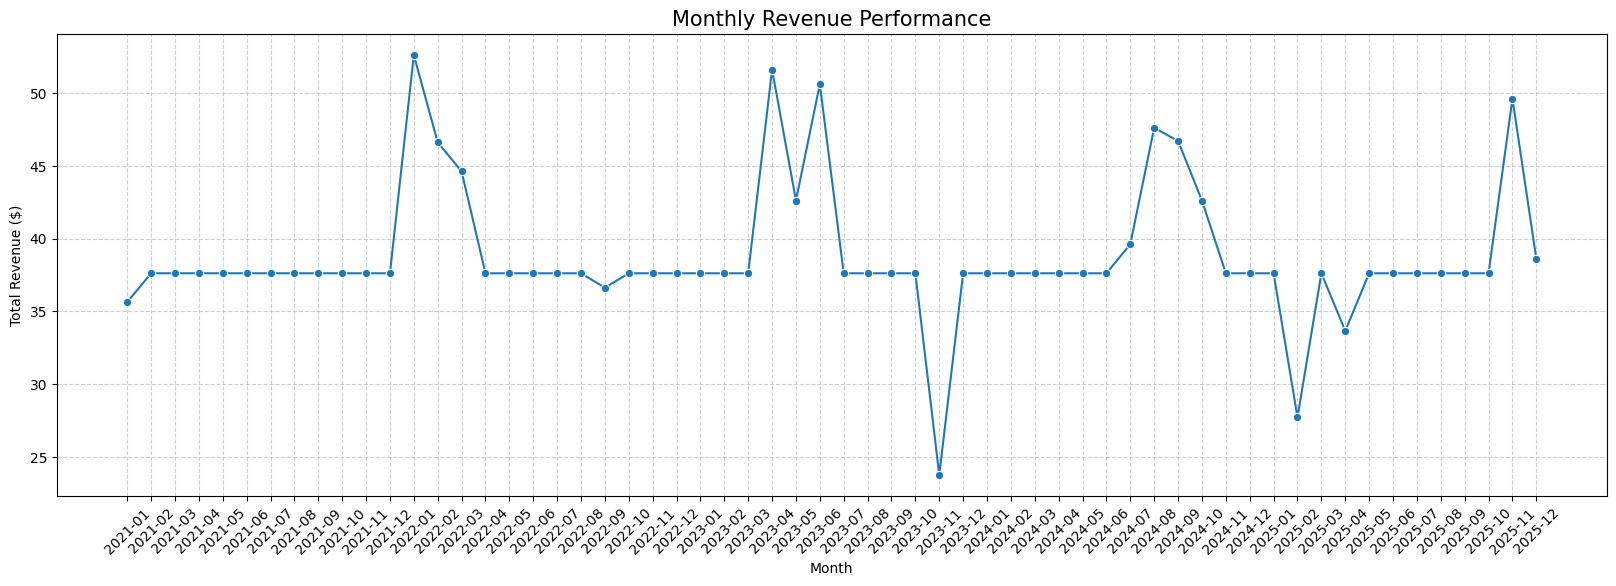

In [7]:
# Monthly Performance Visualization

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
sns.lineplot(data=monthly_perf, x='month', y='monthly_revenue', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Performance', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()